<a href="https://colab.research.google.com/github/technobonal/2199-python-y-gemini-orquestando-llms-con-langchain/blob/main/CursoFabricioRAGyagentesdeIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y langchain langchain-core langchain-community langchain-text-splitters langchain-groq langchain-cohere transformers sentence-transformers -q
!pip install -q langchain langchain-community langchain-text-splitters langchain-groq langchain-cohere pypdf faiss-cpu

In [ ]:
!pip install -q langchain langchain-google-genai google-generativeai langchain-groq

In [ ]:
# ==================== CELDA 1: Cargar claves y crear LLM ====================
from google.colab import userdata
from langchain_groq import ChatGroq

# Cargar las API Keys
GEMNI_API_KEY = userdata.get('GEMNI_API_KEY')
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

# Crear el LLM (Groq es más rápido y económico)
llm = ChatGroq(
    model="llama-3.3-70b-versatile",   # Muy buena opción
    api_key=GROQ_API_KEY,
    temperature=0.2,                   # Más preciso para RRHH
    max_tokens=1024
)

print("✅ LLM creado correctamente")

✅ LLM creado correctamente


In [ ]:
from google.colab import userdata
from langchain_groq import ChatGroq

GROQ_API_KEY = userdata.get('GROQ_API_KEY')

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY
)

In [ ]:
respuesta = llm.invoke("¿Qué es el RAG en Inteligencia Artificial?")

In [ ]:
respuesta.content

'El RAG (Retrieve, Augment, Generate) es un modelo de lenguaje grande desarrollado por Meta AI que combina la recuperación de información (Retrieve), el aumento de contexto (Augment) y la generación de texto (Generate) para responder preguntas y completar tareas de lenguaje natural.\n\nA continuación, te presento una descripción detallada de cada componente del RAG:\n\n1. **Retrieve (Recuperación)**: En este paso, el modelo busca información relevante en una base de conocimientos o en un conjunto de texto grande. El objetivo es encontrar fragmentos de texto que puedan ser útiles para responder a la pregunta o completar la tarea.\n2. **Augment (Aumento)**: Una vez que se han recuperado los fragmentos de texto relevantes, el modelo los combina y los procesa para crear un contexto más amplio y detallado. Esto puede incluir la identificación de entidades, la extracción de relaciones y la inferencia de información implícita.\n3. **Generate (Generación)**: Finalmente, el modelo utiliza el co

In [ ]:
PROMPT_TRIAJE = """
Eres un especialista en triaje del Service Desk para politicas internas.
Dado el mensaje del usuario, devuelve SÓLO un JSON con:\n
{\n
    "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET",\n
    "urgencia": "BAJA" | "MEDIANA" | "ALTA",\n
    "campos_faltantes": ["..."]\n
}\n
Reglas:\n
- **AUTO_RESOLVER**: Preguntas claras sobre las reglas o procedimientos descritos en las politicas (Ej.: "¿Puedo reembolsar el internet para mi oficina en casa?").\n
- **PEDIR_INFO**: Mensajes imprecisos o sin información para identificar el tema o el contexto (Ej.: "Necesito ayuda con una politica").\n
- **ABRIR_TICKET**: Solicitudes de excepciones, autorización, aprobación o acceso especial, o cuando el usuario solicita explicitamente abrir un ticket (Ej.: "Quiero una excepción para trabajar remotamente durante 5 dias").\n
Analiza el mensaje y decide la acción más adecuada.
"""

In [ ]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
    decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"]
    urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
    campos_faltantes: List[str] = Field(default_factory=list)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(state: AgentState) -> AgentState:
    mensaje = state["pregunta"]
    salida: TriajeOut = chain_de_triaje.invoke(
        [
            SystemMessage(content=PROMPT_TRIAJE),
            HumanMessage(content=mensaje)
        ]
    )
    return {"triaje": salida.model_dump()}  # ← guarda todo bajo "triaje"

In [ ]:
mensajes_de_prueba = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepción para teletrabajar durante 5 días.",
    "¿Cómo funciona la política de comidas para viajes?",
    "¿Existe una política para anticipos de vacaciones?",
    "¿Quién fue Napoleón Bonaparte?"
]

for pregunta in mensajes_de_prueba:
    r = triaje(pregunta)
    print(f"{pregunta} -> {r}")

¿Puedo obtener un reembolso por el internet de mi home office? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
Quiero una excepción para teletrabajar durante 5 días. -> {'decision': 'ABRIR_TICKET', 'urgencia': 'MEDIANA', 'campos_faltantes': []}
¿Cómo funciona la política de comidas para viajes? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
¿Existe una política para anticipos de vacaciones? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
¿Quién fue Napoleón Bonaparte? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'campos_faltantes': ['información relevante sobre políticas internas']}


# RAG

In [ ]:
!pip install -q pypdf

In [ ]:
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader  # ← cambia PyMuPDF por PyPDF
from langchain_text_splitters import RecursiveCharacterTextSplitter

docs = []
for documento in Path("/content/").glob("*.pdf"):
    loader = PyPDFLoader(str(documento))
    docs.extend(loader.load())
    print(f"Cargado: {documento.name}")

print(f"Total docs: {len(docs)}")

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

print(f"Total chunks: {len(chunks)}")

/tmp/ipykernel_33006/2173180051.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader  # ← cambia PyMuPDF por PyPDF


Cargado: Política de Uso de Correo Electrónico y Seguridad de la Información.pdf
Cargado: Política de Teletrabajo (Home Office).pdf
Cargado: Política de Reembolsos (Viajes y Gastos).pdf
Total docs: 3
Total chunks: 35


In [ ]:
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

print(f"Total chunks: {len(chunks)}")

Total chunks: 35


In [ ]:
for chunk in chunks:
    print(chunk)
    print("-----------------")

page_content='Política  de  Uso  de  Correo  Electrónico  
y
 
Seguridad
 
de
 
la
 
Información
 
1.  Propósito  Esta  política  define  el  uso  aceptable  de  los  sistemas  de  correo  electrónico  de  
la
 
empresa
 
y
 
las
 
responsabilidades
 
de
 
los
 
empleados
 
para
 
proteger
 
la
 
información' metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'source': '/content/Política de Uso de Correo Electrónico y Seguridad de la Información.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}
-----------------
page_content='proteger
 
la
 
información
 
corporativa
 
contra
 
accesos
 
no
 
autorizados,
 
pérdida
 
o
 
divulgación.
 
2.  Uso  del  Correo  Electrónico  (E-mail)  
●  Uso  Profesional:  La  cuenta  de  correo  electrónico  es  una  herramienta  de  trabajo  y  
debe
 
usarse
 
principalmente
 
para' metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creato

In [ ]:
len(chunks)

35

In [ ]:
from langchain_cohere import CohereEmbeddings
from google.colab import userdata

COHERE_API_KEY = userdata.get('COHERE_API_KEY')

modelo_embeddings = CohereEmbeddings(
    model="embed-multilingual-v3.0",
    cohere_api_key=COHERE_API_KEY
)

In [ ]:
print(f"Cantidad de chunks: {len(chunks)}")
print(f"Primer chunk: {chunks[0] if chunks else 'VACÍO'}")

Cantidad de chunks: 35
Primer chunk: page_content='Política  de  Uso  de  Correo  Electrónico  
y
 
Seguridad
 
de
 
la
 
Información
 
1.  Propósito  Esta  política  define  el  uso  aceptable  de  los  sistemas  de  correo  electrónico  de  
la
 
empresa
 
y
 
las
 
responsabilidades
 
de
 
los
 
empleados
 
para
 
proteger
 
la
 
información' metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'source': '/content/Política de Uso de Correo Electrónico y Seguridad de la Información.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}


In [ ]:
import os

# Verificar si hay PDFs en /content/
pdfs = list(Path("/content/").glob("*.pdf"))
print(f"PDFs encontrados: {pdfs}")

# Verificar si pymupdf está instalado
try:
    import fitz
    print("PyMuPDF instalado ✅")
except ImportError:
    print("PyMuPDF NO instalado ❌")

PDFs encontrados: [PosixPath('/content/Política de Uso de Correo Electrónico y Seguridad de la Información.pdf'), PosixPath('/content/Política de Teletrabajo (Home Office).pdf'), PosixPath('/content/Política de Reembolsos (Viajes y Gastos).pdf')]
PyMuPDF NO instalado ❌


In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.3, "k": 4}
)



In [ ]:
!pip show langchain

Name: langchain
Version: 1.3.11
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 


In [ ]:
!pip install langchain-classic

In [ ]:
!pip install langchain-classic -q

In [ ]:
# ==================== CELDA 2: Prompt + Chain ====================
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate(
    [
        ("system",
            """Eres el especialista en RR.HH. de la empresa Carraro Desarrollo de Software.
            Responde siempre utilizando los conocimientos del contexto que te fue pasadas a ti.
            Si no hay información suficiente sobre la pregunta en el contexto, responde solo 'No lo sé'.
            Sé claro, profesional y útil."""
        ),
        ("human", "Contexto: {context}\n\nPregunta del empleado: {input}")
    ]
)

document_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt_rag
)

print("✅ document_chain creada correctamente")

✅ document_chain creada correctamente


In [ ]:
def busqueda_de_respuestas_RAG(pregunta) -> dict:
    documentos_relacionados = retriever.invoke(pregunta)


    if not documentos_relacionados:
        return {
        "respuesta": "No lo sé",
        "citaciones": [],
        "documentos_encontrados": False
    }

    answer = document_chain.invoke({
        "input": pregunta,
        "context": documentos_relacionados
   })

    if answer.rstrip(".!?") == "No lo sé":
        return {
        "respuesta": "No lo sé",
        "citaciones": [],
        "documentos_encontrados": False
    }

    return {
        "respuesta": answer,
        "citaciones": documentos_relacionados,
        "documentos_encontrados": True
    }


In [ ]:
r = busqueda_de_respuestas_RAG("¿Puedo obtener un reembolso por el internet de mi home office?")
print(r)

{'respuesta': 'Sí, puedes solicitar un reembolso por los gastos de conexión a internet de tu home office. De acuerdo con nuestra política, puedes solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet de alta velocidad estable. Para obtener el reembolso, debes presentar la factura correspondiente a través del sistema "Gestión de Gastos" antes del día 5 del mes siguiente y adjuntar el recibo. Es importante que el gasto haya sido aprobado previamente por tu gerente de departamento.', 'citaciones': [Document(id='0ad1f81c-c976-4db9-a627-0862b091d2c5', metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'source': '/content/Política de Reembolsos (Viajes y Gastos).pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='con\n \nrecibo.\n ●  Internet  (Home  Office):  Los  empleados  bajo  el  modelo  de  trabajo  remoto  (Home  \nOffice)\n \naprobado\n \

In [ ]:
len(r["citaciones"])

4

In [ ]:
mensajes_de_prueba = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepción para teletrabajar durante 5 días.",
    "¿Cómo funciona la política de comidas para viajes?",
    "¿Existe una politica para anticipos de vacaciones?",
    "¿Quién fue Napoleon Bonaparte?"
]

In [ ]:
print(chunks[0].metadata)

{'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'source': '/content/Política de Uso de Correo Electrónico y Seguridad de la Información.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}


In [ ]:
for pregunta in mensajes_de_prueba:
    respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)
    print(f"PREGUNTA: {pregunta}")
    print(f"RESPUESTA: {respuesta_RAG['respuesta']}")
    if respuesta_RAG['documentos_encontrados']:
      for i, citacion in enumerate(respuesta_RAG['citaciones']):
        print(f"           - CITACION {i + 1}:")
        print(f"             Camino del documento: {citacion.metadata['source']}")
        print(f"             Contenido: {citacion.page_content.replace('\n', ' ')}")
    print("-----------------------------------------------------------")

PREGUNTA: ¿Puedo obtener un reembolso por el internet de mi home office?
RESPUESTA: Sí, puedes solicitar un reembolso por el internet de tu home office. De acuerdo con nuestra política, los empleados que trabajan bajo el modelo de trabajo remoto (Home Office) pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet de alta velocidad estable. Para obtener el reembolso, debes presentar la factura correspondiente a través de nuestro sistema de "Gestión de Gastos" antes del día 5 del mes siguiente. Recuerda que es obligatorio adjuntar el recibo y obtener la aprobación previa de tu gerente de departamento.
           - CITACION 1:
             Camino del documento: /content/Política de Reembolsos (Viajes y Gastos).pdf
             Contenido: con   recibo.  ●  Internet  (Home  Office):  Los  empleados  bajo  el  modelo  de  trabajo  remoto  (Home   Office)   aprobado   (ver   Política   de   Home   Office)   pueden   solicitar   un   reembolso   mensual   de  

PREGUNTA: ¿Existe una politica para anticipos de vacaciones?
RESPUESTA: No lo sé. La política proporcionada se refiere a reembolsos de gastos incurridos por los empleados en el ejercicio de sus funciones oficiales, pero no menciona específicamente anticipos de vacaciones. Si necesitas información sobre anticipos de vacaciones, te recomiendo consultar la política de vacaciones o hablar con el departamento de RR.HH. para obtener más información.
           - CITACION 1:
             Camino del documento: /content/Política de Reembolsos (Viajes y Gastos).pdf
             Contenido: Política  de  Reembolsos  (Viajes  y   Gastos)   1.  Objetivo  Establecer  las  directrices  y  procedimientos  para  el  reembolso  de  gastos   incurridos   por   los   empleados   en   el   ejercicio   de   sus   funciones   oficiales,   asegurando   la   transparencia,   equidad   y
           - CITACION 2:
             Camino del documento: /content/Política de Reembolsos (Viajes y Gastos).pdf
            

# Agente LangGraph


In [ ]:
!pip install -q langgraph

In [ ]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total=False):
      pregunta: str
      triaje: dict
      respuesta: Optional[str]
      citaciones: Optional[list]
      documentos_encontrados: Optional[bool]
      rag_exito: bool
      accion_final: str

In [ ]:
def nodo_triage(state: AgentState) -> AgentState:
    print("ejecutando nodo triaje...");
    return {"triage": triaje(state["pregunta"])};

In [ ]:
# CÓDIGO CORRECTO (todo indentado dentro de la función)
def nodo_auto_resolver(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'auto_resolver'...")
    respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])
    update: AgentState = {
        "respuesta": respuesta_RAG["respuesta"],
        "citaciones": respuesta_RAG["citaciones"],
        "rag_exito": respuesta_RAG["documentos_encontrados"]
    }                             # ← cierra el dict con indentación
    if respuesta_RAG["documentos_encontrados"]:   # ← dentro de la función
        update["accion_final"] = "AUTO_RESOLVER"
    else:
        update["accion_final"] = "pedir_info"
    return update                 # ← dentro de la función



In [ ]:
def nodo_pedir_info(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'pedir_info'...");
    return {
        "respuesta": "Necesito más informaciones sobre tu pedido.",
        "citaciones": [],
        "accion_final": "PEDIR_INFO"
    }

In [ ]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'abrir_ticket'...");
    tri = state["triaje"];
    return {
        "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. Pedido: {state['pregunta']}.",
        "citaciones": [],
        "accion_final": "ABRIR_TICKET"
    }

In [ ]:
def arista_decision_triaje(state: AgentState) -> str:
    print("Decidiendo el flujo después del nodo 'triaje'...")
    tri = state["triaje"]  # ← ahora sí existe

    if tri["decision"] == "AUTO_RESOLVER":
        return "rag"
    elif tri["decision"] == "ABRIR_TICKET":
        return "ticket"
    else:
        return "info"

In [ ]:
# CÓDIGO CORRECTO
KEYWORDS_ABRIR_TICKET = [        # ← esta variable va FUERA, antes de la función
    "aprobación", "aprobar", "excepción", "liberación", "autorización",
    "autorizar", "abrir ticket", "acceso especial"
]

def arista_decision_rag(state: AgentState) -> str:
    print("Decidiendo el flujo después del nodo 'auto_resolver'...")
    if state["rag_exito"]:
        print("RAG con exito, finalizando el flujo.")
        return "ok"
    if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_ABRIR_TICKET):
        print("RAG ha fallado, pero hay palabras relacionadas con abrir ticket.")
        return "ticket"
    print("RAG ha fallado, pediré más informaciones al usuario.")
    return "info"



In [ ]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

grafo = workflow.compile();

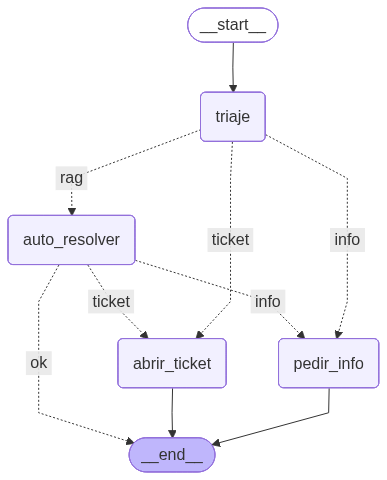

In [ ]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [ ]:
PREGUNTA = "Puedo reembolsar mi internet?"

temp = grafo.invoke({"pregunta": PREGUNTA})
print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISION DE TRIAJE: {temp['triaje']['decision']} | URGENCIA: {temp['triaje']['urgencia']} | ACCIÓN FINAL: {temp['accion_final']}")
print(f"RESPUESTA: {temp['respuesta']}")
if temp['citaciones']:
    for i, citacion in enumerate(temp['citaciones']):
        print(f"  - CITACION {i+1}: {citacion.metadata['source']}")
        print(f"             Contenido: {citacion.page_content.replace('\n', ' ')}")
        print("-----------------------------------------------------------")

Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con exito, finalizando el flujo.
PREGUNTA: Puedo reembolsar mi internet?
DECISION DE TRIAJE: AUTO_RESOLVER | URGENCIA: BAJA | ACCIÓN FINAL: AUTO_RESOLVER
RESPUESTA: Sí, puedes solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, siempre y cuando estés trabajando bajo el modelo de trabajo remoto (Home Office) y sigas la política de reembolsos establecida. Para solicitar el reembolso, debes presentar la factura correspondiente a través del sistema "Gestión de Gastos" antes del día 5 del mes siguiente.
  - CITACION 1: /content/Política de Reembolsos (Viajes y Gastos).pdf
             Contenido: con   recibo.  ●  Internet  (Home  Office):  Los  empleados  bajo  el  modelo  de  trabajo  remoto  (Home   Office)   aprobado   (ver   Política   de   Home   Office)   pueden   solicitar   un   reembolso   mensual   de   hasta

In [ ]:
PREGUNTA = "Puedo reembolsar mi internet?"
temp = grafo.invoke({"pregunta": PREGUNTA})

print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISIÓN: {temp['triaje']['decision']} | URGENCIA: {temp['triaje']['urgencia']}")
print(f"\nRESPUESTA:\n{temp['respuesta']}")

if temp['citaciones']:
    print("\nFUENTES:")
    for i, citacion in enumerate(temp['citaciones']):
        fuente = citacion.metadata['source'].split('/')[-1]  # solo el nombre del archivo
        contenido = ' '.join(citacion.page_content.split())  # limpia espacios extra
        print(f"\n  [{i+1}] {fuente}")
        print(f"  {contenido[:150]}...")  # muestra solo los primeros 150 caracteres

Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con exito, finalizando el flujo.
PREGUNTA: Puedo reembolsar mi internet?
DECISIÓN: AUTO_RESOLVER | URGENCIA: BAJA

RESPUESTA:
Sí, puedes solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet si trabajas bajo el modelo de trabajo remoto (Home Office) y cumples con los requisitos establecidos en la Política de Reembolsos. Para ello, debes presentar la factura correspondiente a través del sistema "Gestión de Gastos" antes del día 5 del mes siguiente.

FUENTES:

  [1] Política de Reembolsos (Viajes y Gastos).pdf
  con recibo. ● Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado (ver Política de Home Office) pueden solic...

  [2] Política de Teletrabajo (Home Office).pdf
  conexión a internet de alta velocidad estable. 6. Reembolsos Asociados Como se detalla en la "Política de R

In [ ]:
import textwrap

PREGUNTA = "Puedo reembolsar mi internet?"
temp = grafo.invoke({"pregunta": PREGUNTA})

print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISIÓN: {temp['triaje']['decision']} | URGENCIA: {temp['triaje']['urgencia']}| ACCIÓN FINAL: {temp['accion_final']}")

print(f"\nRESPUESTA:")
print(textwrap.fill(temp['respuesta'], width=80))

if temp['citaciones']:
    print("\nFUENTES:")
    for i, citacion in enumerate(temp['citaciones']):
        fuente = citacion.metadata['source'].split('/')[-1]
        contenido = ' '.join(citacion.page_content.split())
        print(f"\n  [{i+1}] {fuente}")
        print(textwrap.fill(contenido, width=80, initial_indent="  ", subsequent_indent="  "))
    print("---")

Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con exito, finalizando el flujo.
PREGUNTA: Puedo reembolsar mi internet?
DECISIÓN: AUTO_RESOLVER | URGENCIA: BAJA

RESPUESTA:
Sí, puedes solicitar un reembolso mensual de hasta 35 EUR para gastos de
conexión a internet si trabajas bajo el modelo de trabajo remoto (Home Office) y
cumples con los requisitos establecidos en la Política de Reembolsos. Para
solicitar el reembolso, debes presentar la factura correspondiente a través del
sistema "Gestión de Gastos" antes del día 5 del mes siguiente.

FUENTES:

  [1] Política de Reembolsos (Viajes y Gastos).pdf
  con recibo. ● Internet (Home Office): Los empleados bajo el modelo de trabajo
  remoto (Home Office) aprobado (ver Política de Home Office) pueden solicitar
  un reembolso mensual de hasta 35 EUR para gastos de conexión a internet,

  [2] Política de Teletrabajo (Home Office).pdf
  conexión a 

In [ ]:
import textwrap

for prueba in mensajes_de_prueba:
    respuesta = grafo.invoke({"pregunta": prueba})
    print(f"\nPREGUNTA: {prueba}")
    print(f"DECISIÓN: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")

    if respuesta.get('respuesta'):
        print(f"\nRESPUESTA:")
        print(textwrap.fill(respuesta['respuesta'], width=80))

    if respuesta.get('citaciones'):
        print("\nFUENTES:")
        for i, citacion in enumerate(respuesta['citaciones']):
            fuente = citacion.metadata['source'].split('/')[-1]
            contenido = ' '.join(citacion.page_content.split())
            print(f"\n  [{i+1}] {fuente}")
            print(textwrap.fill(contenido, width=80, initial_indent="  ", subsequent_indent="  "))

    print("---------------------------------")

Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con exito, finalizando el flujo.

PREGUNTA: ¿Puedo obtener un reembolso por el internet de mi home office?
DECISIÓN: AUTO_RESOLVER | URGENCIA: BAJA | ACCIÓN FINAL: AUTO_RESOLVER

RESPUESTA:
Sí, puedes obtener un reembolso por el internet de tu home office. De acuerdo
con nuestra política, los empleados que trabajan bajo el modelo de trabajo
remoto (Home Office) pueden solicitar un reembolso mensual de hasta 35 EUR para
gastos de conexión a internet de alta velocidad estable. Para obtener el
reembolso, debes presentar la factura correspondiente a través del sistema
"Gestión de Gastos" antes del día 5 del mes siguiente. Recuerda que es
obligatorio adjuntar el recibo y obtener la aprobación previa de tu gerente de
departamento.

FUENTES:

  [1] Política de Reembolsos (Viajes y Gastos).pdf
  con recibo. ● Internet (Home Office): Los empleados bajo 